# BipedalWalker：DR、MAC、Target、P2E

统一使用 **8 个连续字段 MSE 与 2 个真实 contact 切换样本 focal loss 的等权平均**。阴影/误差棒为 seed 间样本标准差（ddof=1）。

最终结果在 200,000 条用于 WM 训练的新样本预算下比较；各方法更新次数不同：DR/MAC 50、Target 20、P2E 100。DR/MAC 使用此前最终 checkpoint 重算结果，Target/P2E 使用新运行 CSV。旧 DR/MAC CSV 的原始 loss 不混入此图。

历史曲线仅使用可完整恢复的新口径记录：DR 只有 seed 0；MAC 只有前 12 次更新的部分记录。图例标明每个位置的 seed 数范围，单 seed 不画标准差阴影。横轴排除 MAC warmup 和额外 LP probe 数据，因此不是总环境交互次数。

Run All 会重新读取本地结果。缺失方法会明确显示提示，补齐 P2E 后无需修改代码。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'trainer/conf/config_mac.yaml').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('请从项目目录启动 Jupyter。')
OUT = ROOT / 'outputs/jupyter'
METHODS = ['DR', 'MAC', 'Target', 'P2E']
COLORS = dict(zip(METHODS, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']))

historical = pd.read_csv(OUT / 'bipedal_contact_changed_history.csv')
historical['WM_training_samples'] = historical['WM_updates'] * 4000
historical['Source'] = 'Recovered full-precision historical log'
curves = [historical]
final = pd.read_csv(OUT / 'bipedal_contact_changed_validation.csv').rename(
    columns={'Total_validation_loss': 'Target_loss'})
final['WM_training_samples'] = 200000
final['Source'] = 'Final checkpoint re-evaluation'
finals = [final[['Method', 'Seed', 'WM_updates', 'WM_training_samples', 'Target_loss', 'Source']]]
missing = []
for method, folder in [('Target', 'bipedal_target_new'), ('P2E', 'bipedal_p2e_new')]:
    paths = sorted((ROOT / 'test' / folder).glob('seed*/results/**/*.csv'))
    if not paths:
        missing.append(method)
        print(f'MISSING: {method}; expected test/{folder}/seed*/results/**/*.csv')
        continue
    parts = []
    for path in paths:
        df = pd.read_csv(path)
        budget_column = 'cumulative_data_size' if method == 'Target' else 'Cumulative_Transitions'
        required = {'Seed', 'Iter', budget_column, 'target_val_avg_val_loss_wm'}
        if not required.issubset(df.columns):
            raise ValueError(f'{path}: missing columns {required - set(df.columns)}')
        df = df.rename(columns={'Iter': 'WM_updates', budget_column: 'WM_training_samples',
                                'target_val_avg_val_loss_wm': 'Target_loss'})
        df['Method'] = method
        df['Source'] = str(path.relative_to(ROOT))
        parts.append(df[['Method', 'Seed', 'WM_updates', 'WM_training_samples', 'Target_loss', 'Source']])
    df = pd.concat(parts, ignore_index=True).sort_values(['Seed', 'WM_updates'])
    if df.duplicated(['Seed', 'WM_updates']).any() or not np.isfinite(df.Target_loss).all():
        raise ValueError(f'{method}: duplicate or non-finite validation results')
    for seed, group in df.groupby('Seed'):
        if not np.array_equal(group.WM_updates, np.arange(1, len(group) + 1)):
            raise ValueError(f'{method} seed {seed}: missing training updates')
        if not group.WM_training_samples.is_monotonic_increasing:
            raise ValueError(f'{method} seed {seed}: non-monotonic sample budget')
    curves.append(df)
    endpoint = df.groupby('Seed', sort=True).tail(1)
    if set(endpoint.Seed) != set(range(5)) or not (endpoint.WM_training_samples == 200000).all():
        raise ValueError(f'{method}: final comparison requires seeds 0–4 at 200000 samples')
    finals.append(endpoint)

curve_data = pd.concat(curves, ignore_index=True)
final_data = pd.concat(finals, ignore_index=True)
if final_data.duplicated(['Method', 'Seed']).any():
    raise ValueError('Duplicate final seed results')
for method, group in final_data.groupby('Method'):
    if set(group.Seed) != set(range(5)) or not np.isfinite(group.Target_loss).all():
        raise ValueError(f'{method}: invalid final five-seed results')
summary = final_data.groupby('Method').Target_loss.agg(['mean', 'std', 'count']).reindex(
    [m for m in METHODS if m in set(final_data.Method)])
curve_data.to_csv(OUT / 'bipedal_four_methods_curve_data.csv', index=False)
final_data.to_csv(OUT / 'bipedal_four_methods_final_data.csv', index=False)
summary.to_csv(OUT / 'bipedal_four_methods_summary.csv')
print(summary.to_string())


            mean       std  count
Method                           
DR      0.257179  0.029611      5
MAC     0.230473  0.004835      5
Target  0.270855  0.017130      5
P2E     0.292057  0.071501      5


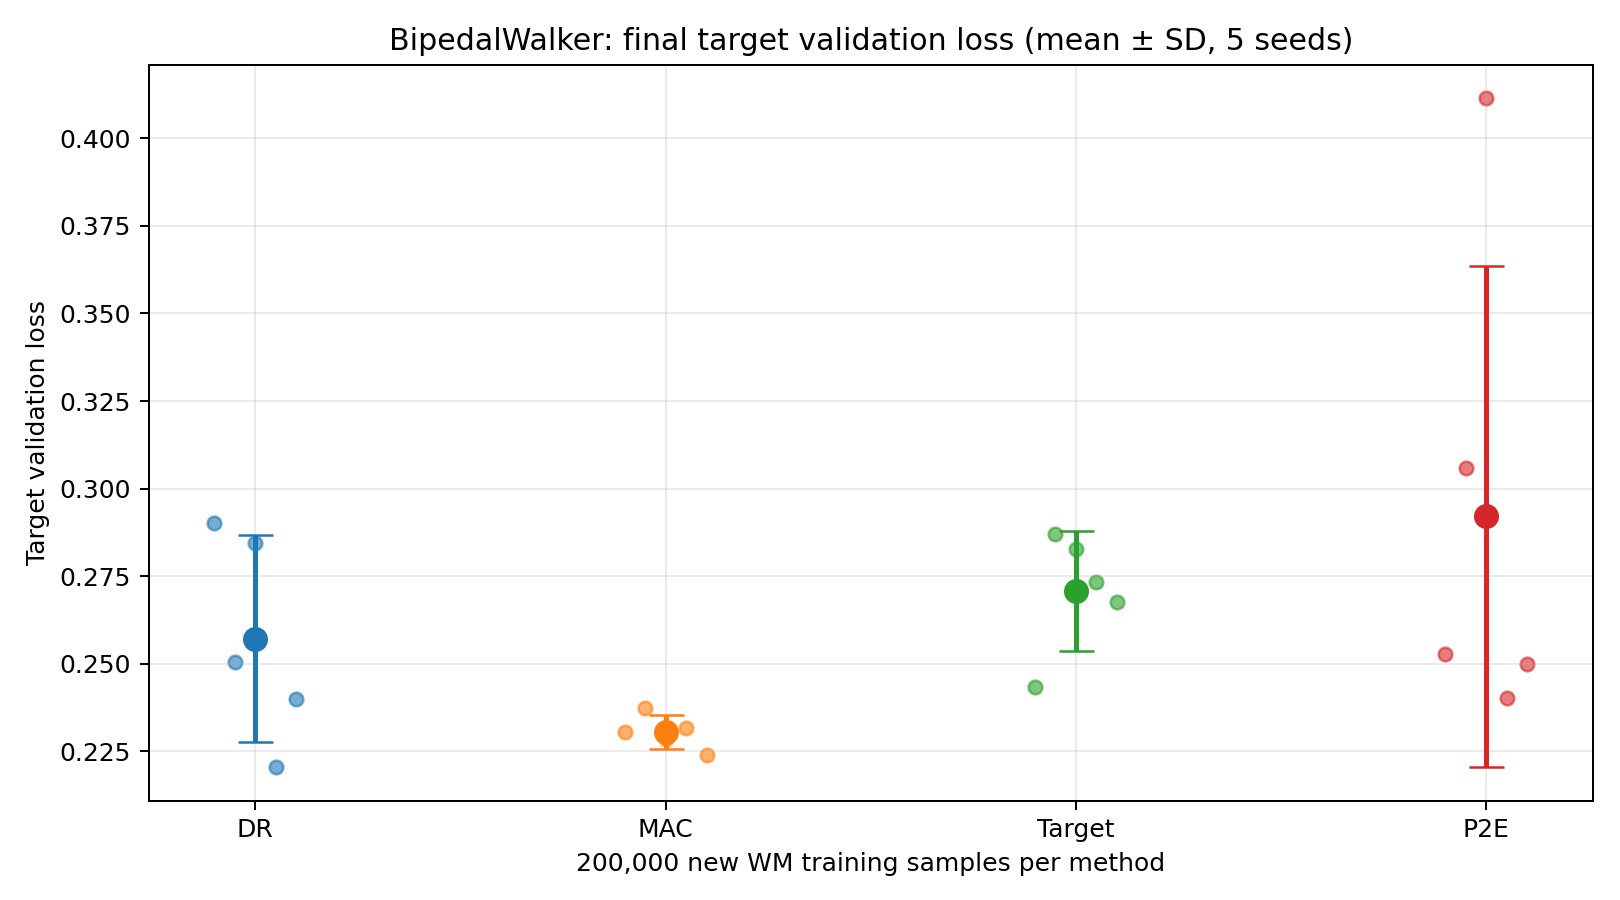

In [2]:
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})
fig, ax = plt.subplots(figsize=(9, 5))
for x, method in enumerate(summary.index):
    values = final_data.loc[final_data.Method == method].sort_values('Seed').Target_loss.to_numpy()
    ax.errorbar(x, summary.loc[method, 'mean'], yerr=summary.loc[method, 'std'],
                fmt='o', color=COLORS[method], capsize=7, markersize=9, linewidth=2)
    ax.scatter(x + np.linspace(-0.10, 0.10, len(values)), values,
               color=COLORS[method], alpha=0.6, s=30)
ax.set_xticks(range(len(summary)), summary.index)
ax.set(title='BipedalWalker: final target validation loss (mean ± SD, 5 seeds)',
       ylabel='Target validation loss', xlabel='200,000 new WM training samples per method')
if missing:
    ax.text(0.02, 0.98, 'Missing results: ' + ', '.join(missing), transform=ax.transAxes,
            va='top', color='firebrick')
fig.tight_layout()
fig.savefig(OUT / 'bipedal_four_methods_final.png', dpi=180)
plt.show()


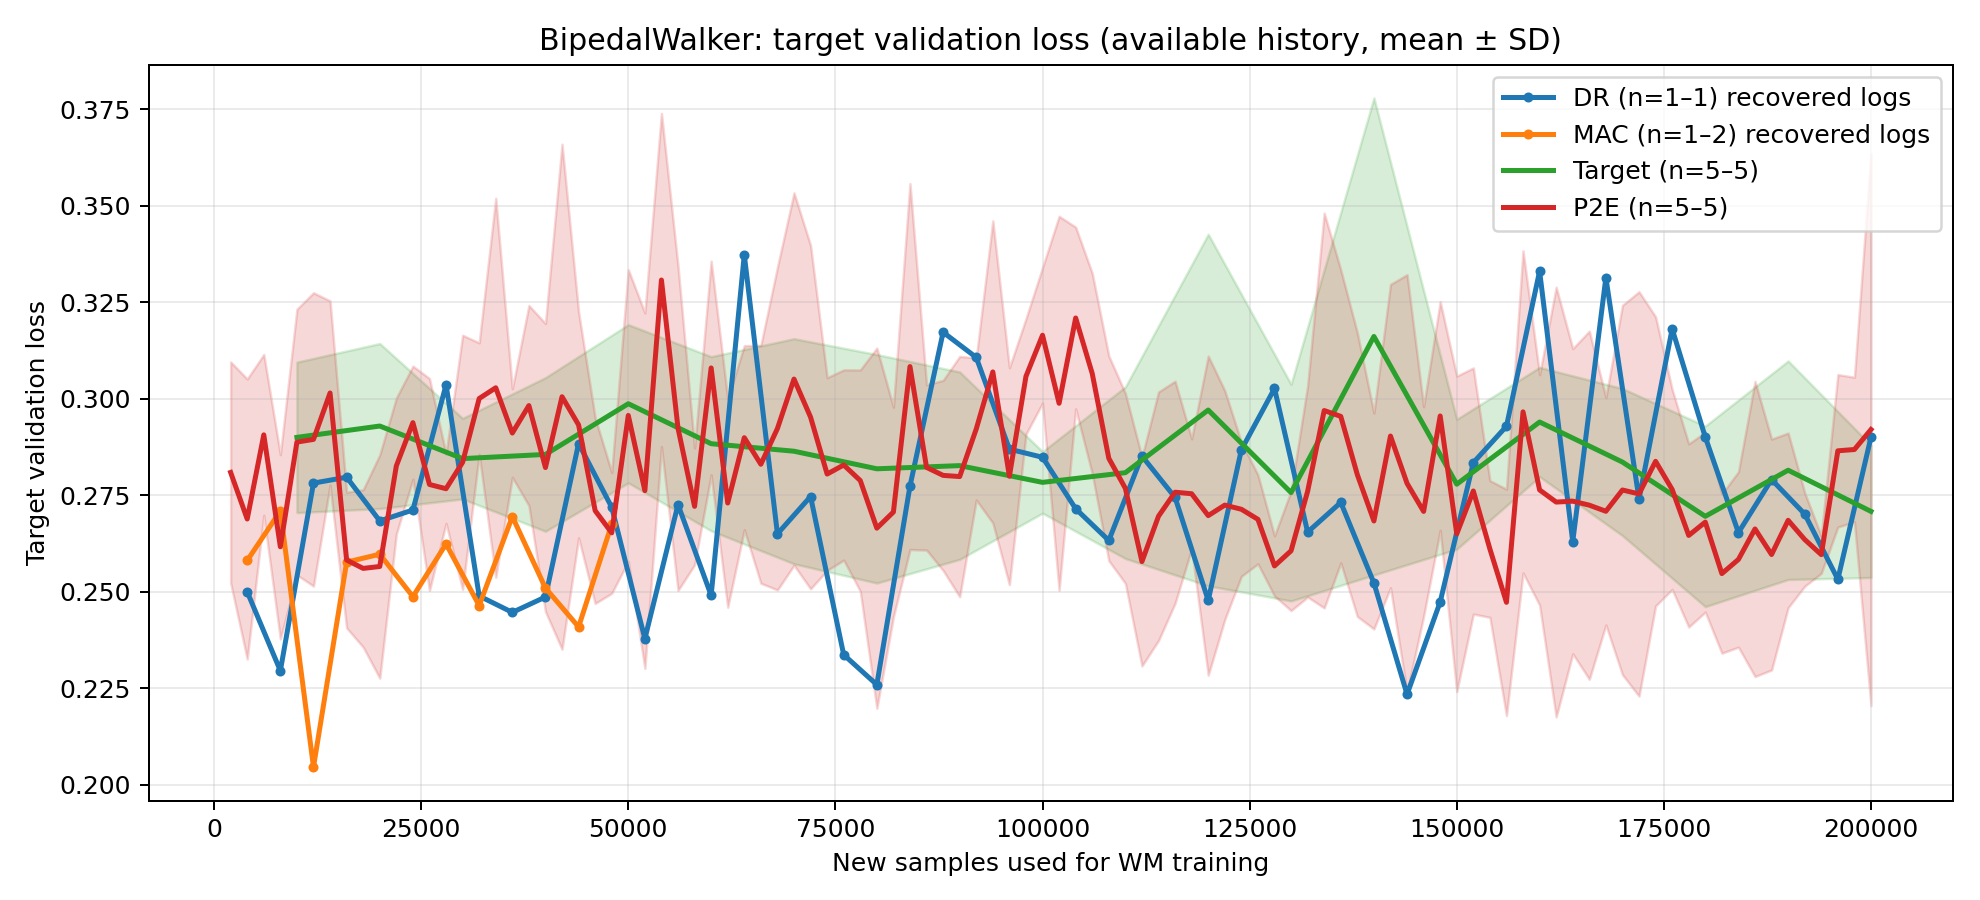

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for method in METHODS:
    df = curve_data.loc[curve_data.Method == method]
    if df.empty:
        continue
    stats = df.groupby('WM_training_samples').Target_loss.agg(['mean', 'std', 'count'])
    counts = stats['count']
    label = f'{method} (n={counts.min()}–{counts.max()})'
    if method in ['DR', 'MAC']:
        label += ' recovered logs'
    x = stats.index.to_numpy()
    ax.plot(x, stats['mean'], color=COLORS[method], linewidth=2,
            marker='.' if method in ['DR', 'MAC'] else None, label=label)
    valid = counts.to_numpy() > 1
    ax.fill_between(x, (stats['mean'] - stats['std']).to_numpy(),
                    (stats['mean'] + stats['std']).to_numpy(), where=valid,
                    color=COLORS[method], alpha=0.18)
ax.set(title='BipedalWalker: target validation loss (available history, mean ± SD)',
       xlabel='New samples used for WM training', ylabel='Target validation loss')
ax.ticklabel_format(axis='x', style='plain')
ax.legend()
if missing:
    ax.text(0.98, 0.98, 'Missing results: ' + ', '.join(missing), transform=ax.transAxes,
            ha='right', va='top', color='firebrick')
fig.tight_layout()
fig.savefig(OUT / 'bipedal_four_methods_learning_curve.png', dpi=180)
plt.show()
